In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
folder = Path('./output/2025-12-01_12h07m50s_reconstr_grid_1')
dev = pd.read_csv(folder/'dev.csv')
test = pd.read_csv(folder/'test.csv')

In [3]:
# compiling dfs
folder = Path('./output/2025-12-01_12h07m50s_reconstr_grid_1')
dev = pd.read_csv(folder/'dev.csv')
test = pd.read_csv(folder/'test.csv')

# subfolders = ['t1', 't2', 't3', 't4', 't5', 't6']
# dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
# test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

# get confs, update
confs = ConfigLookup(
    keys=['embed_dim', 'hidden_dims', 'lr'],
    configs=dev['config'].unique().tolist(),
    path=folder,
    save=True,
).data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

# add log10lr
dev['log10lr'] = np.log10(dev['lr'])
test['log10lr'] = np.log10(test['lr'])

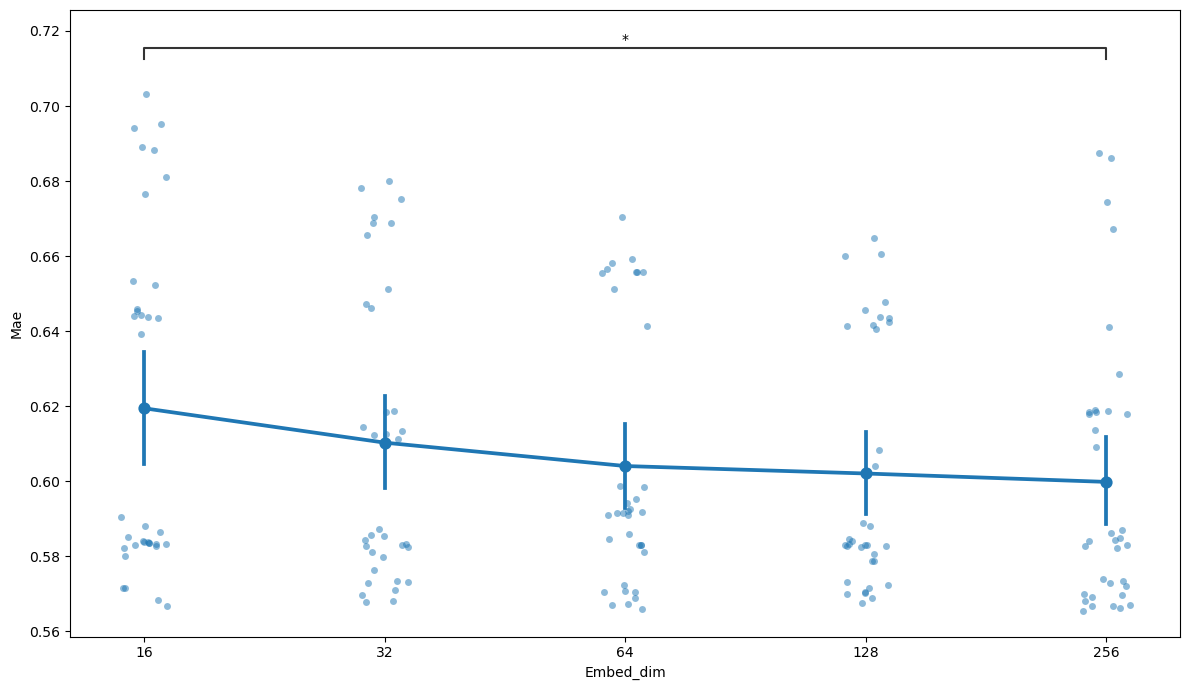

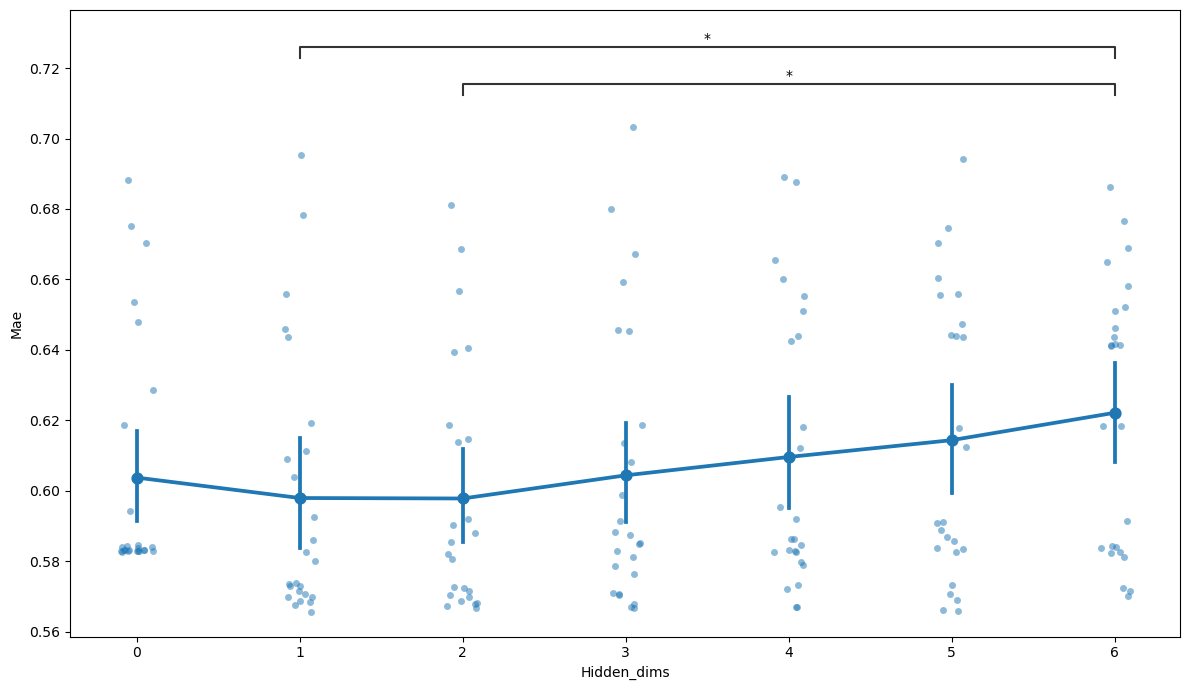

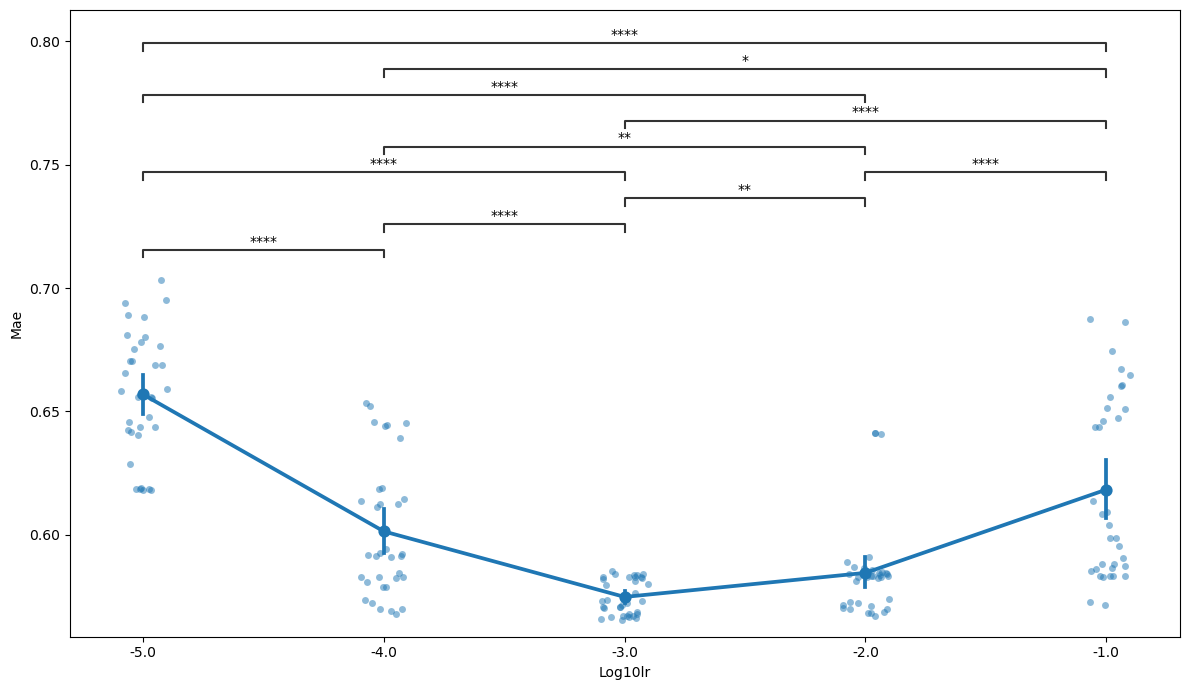

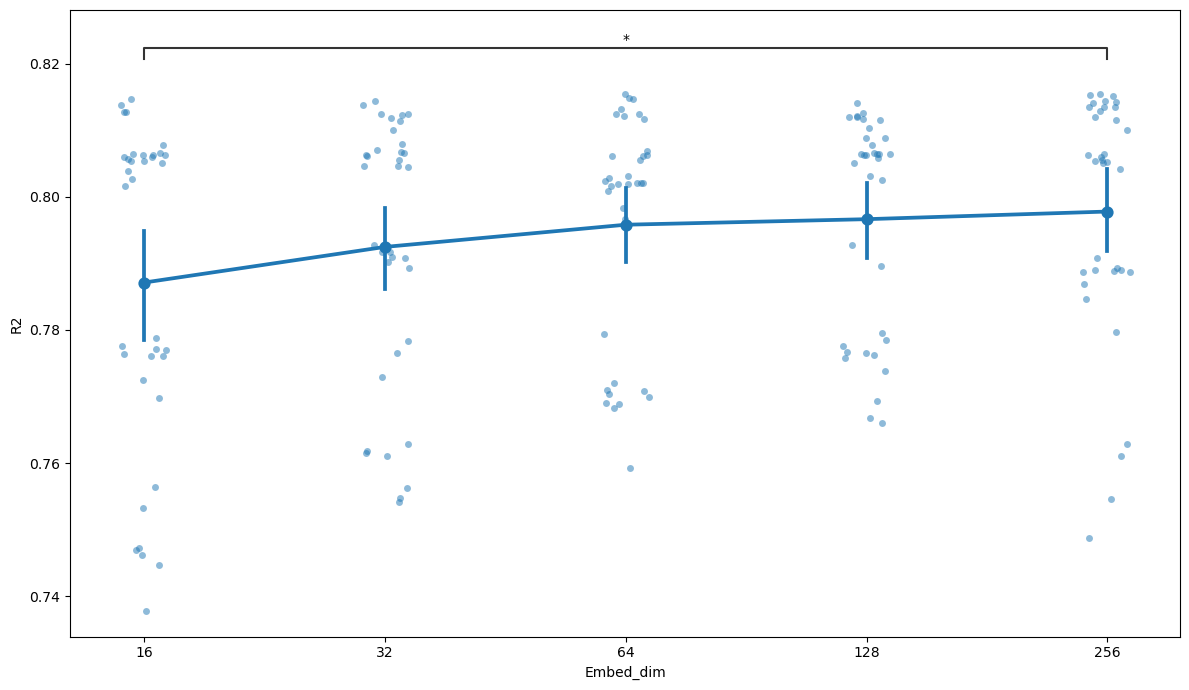

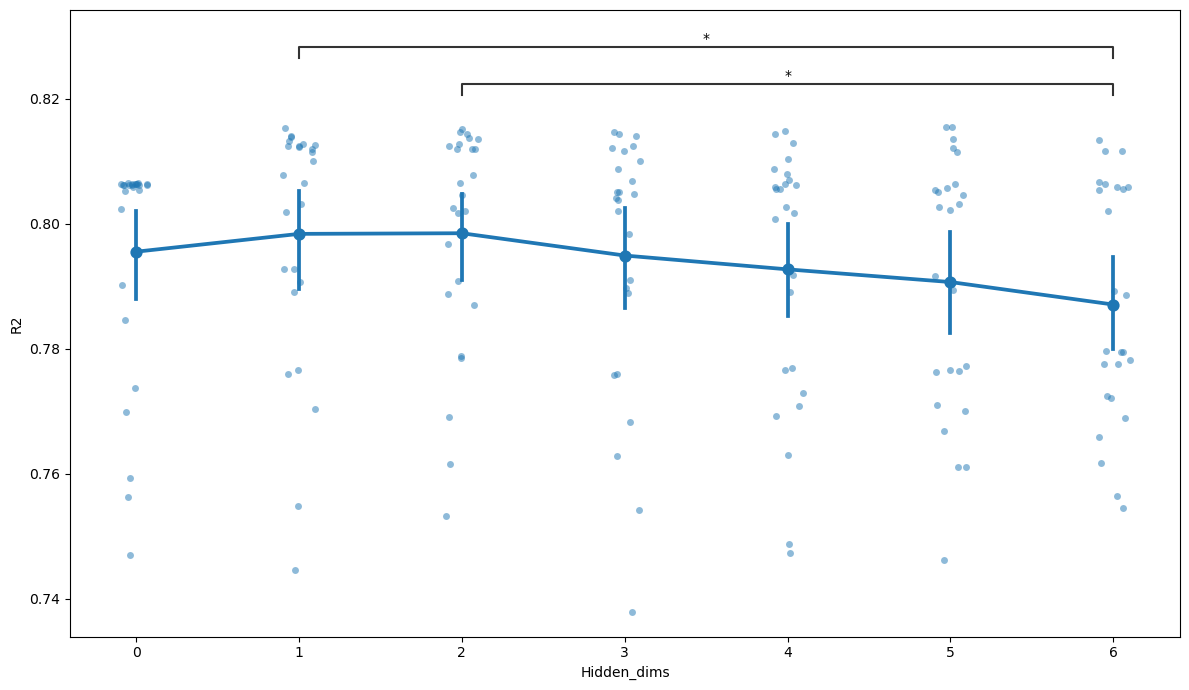

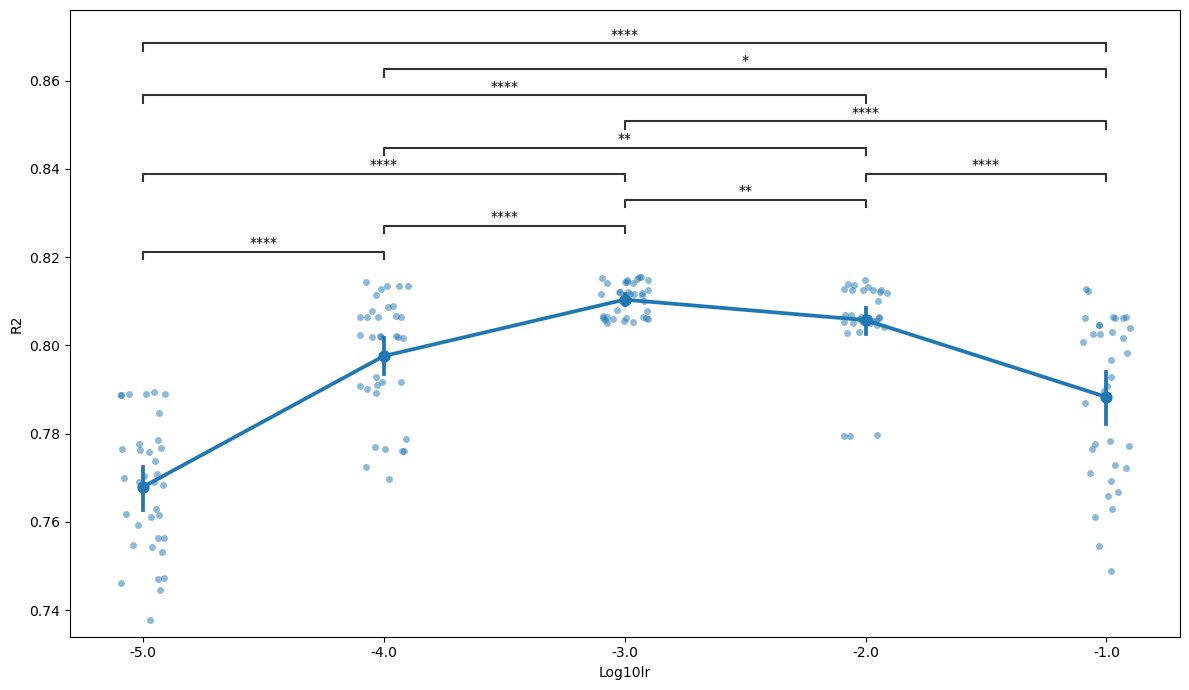

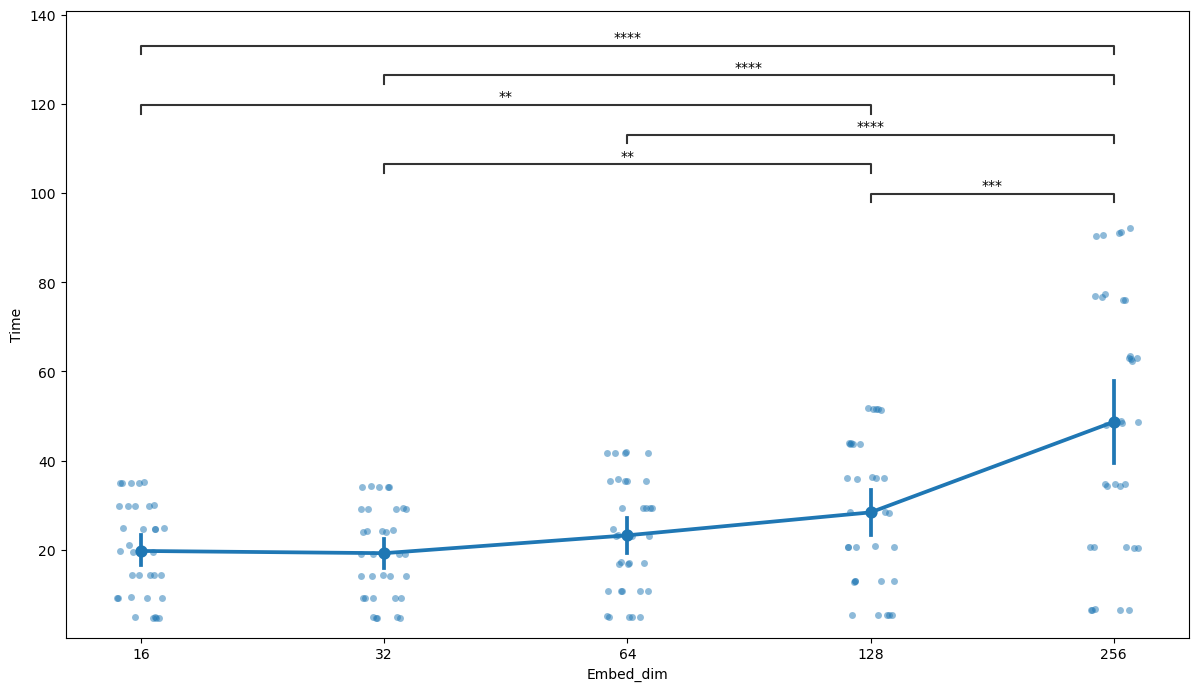

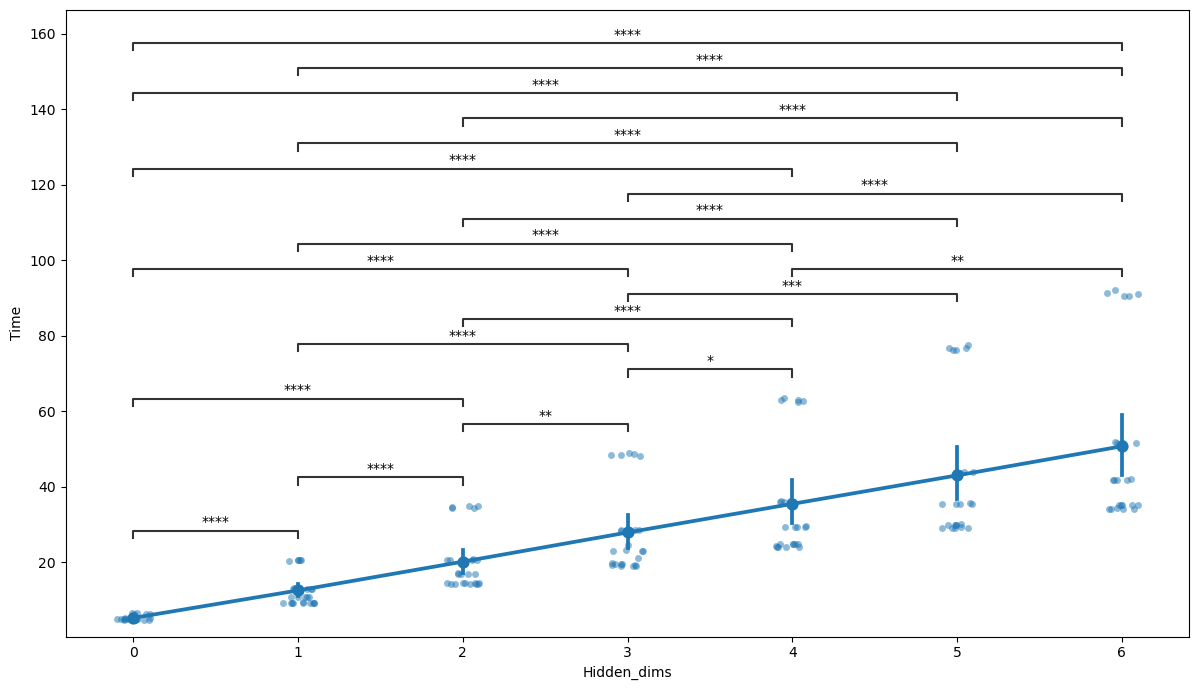

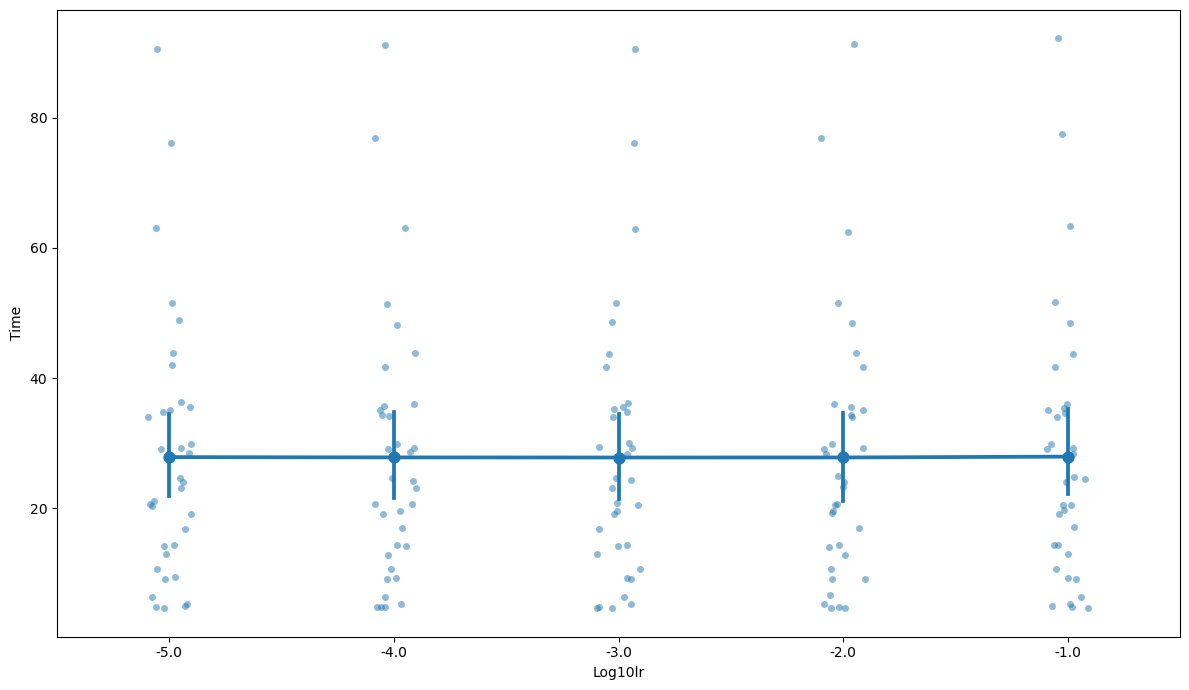

In [4]:
metric_x_point(
    df=test, 
    cols=['embed_dim', 'hidden_dims', 'log10lr'],
    metrics=['mae','r2','time'],
    figsize=(12,7),
    strip=True,
    sig=True
)

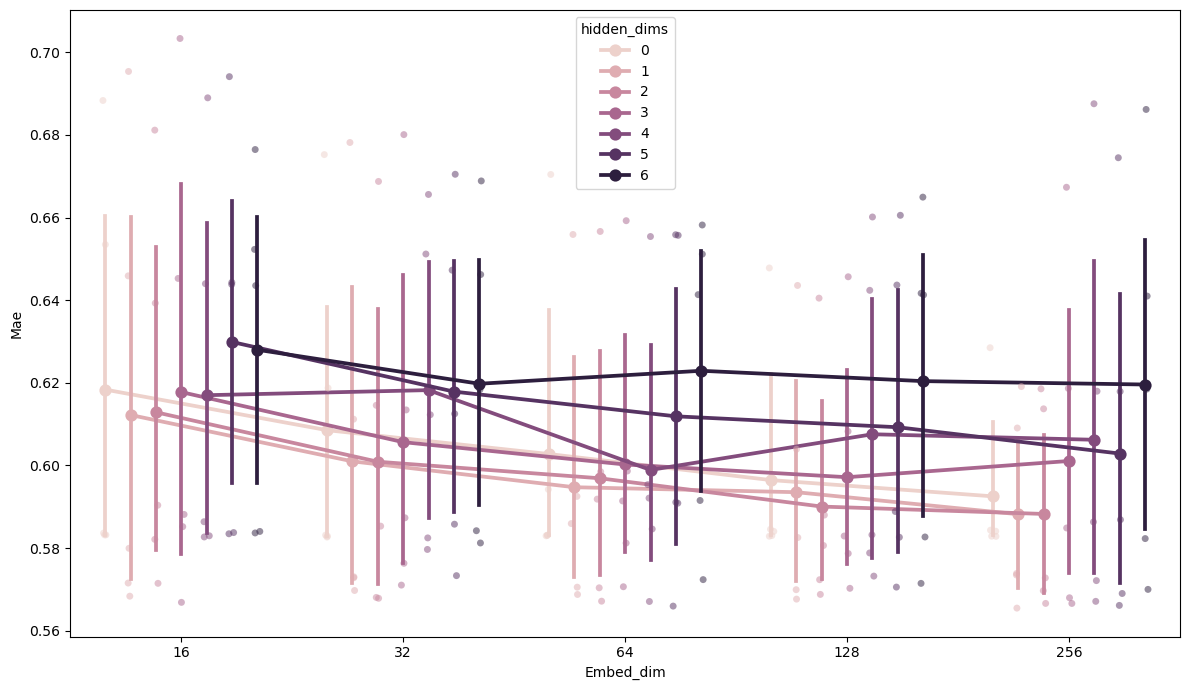

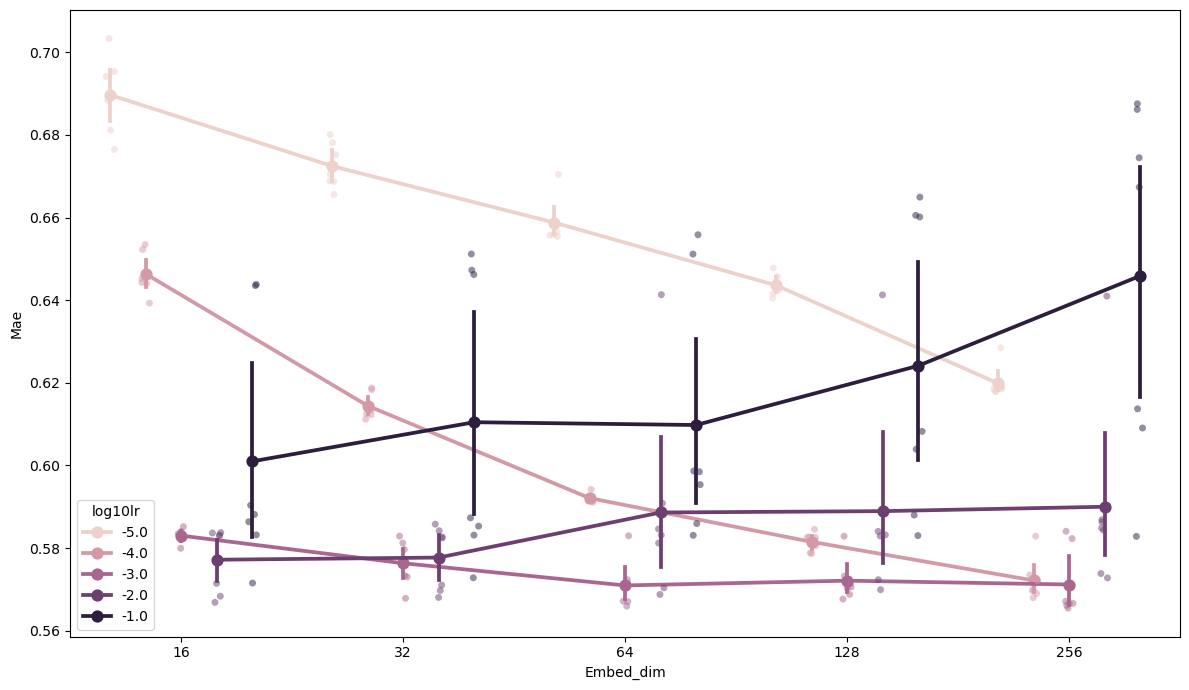

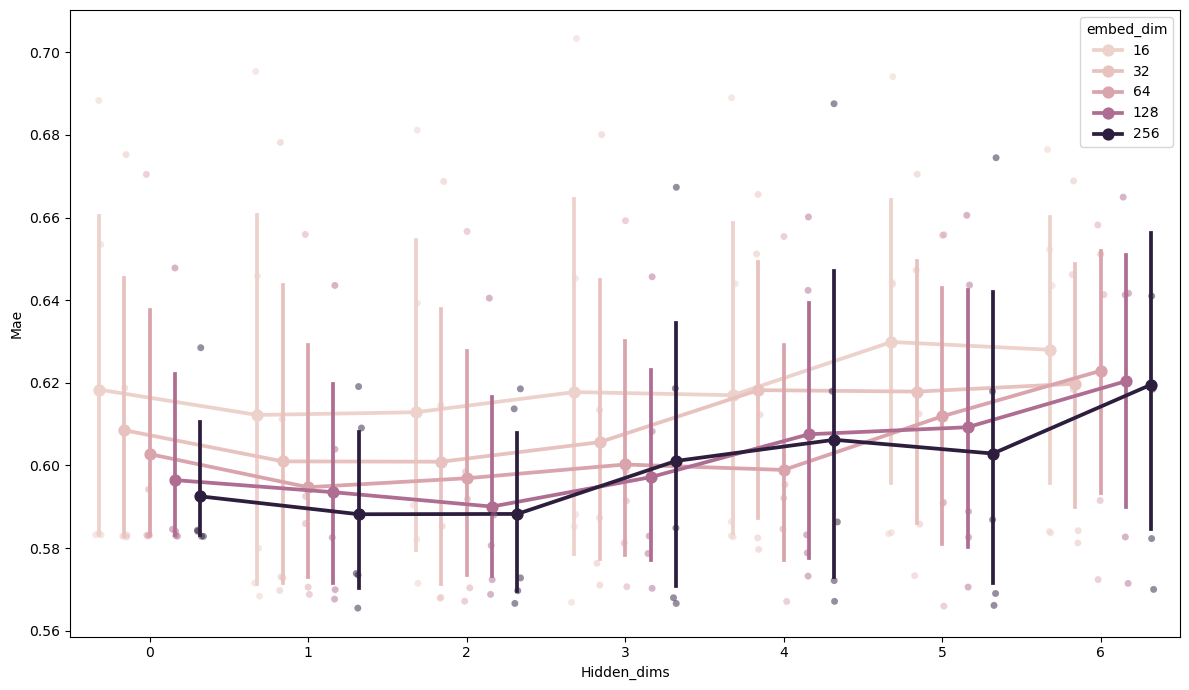

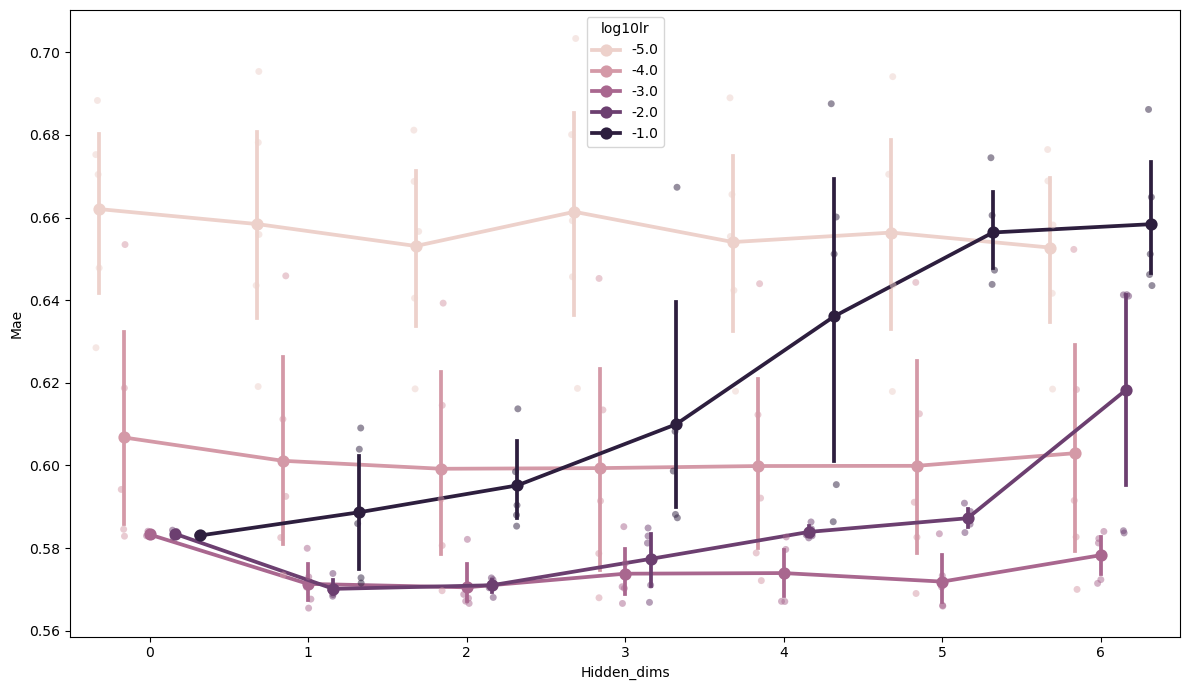

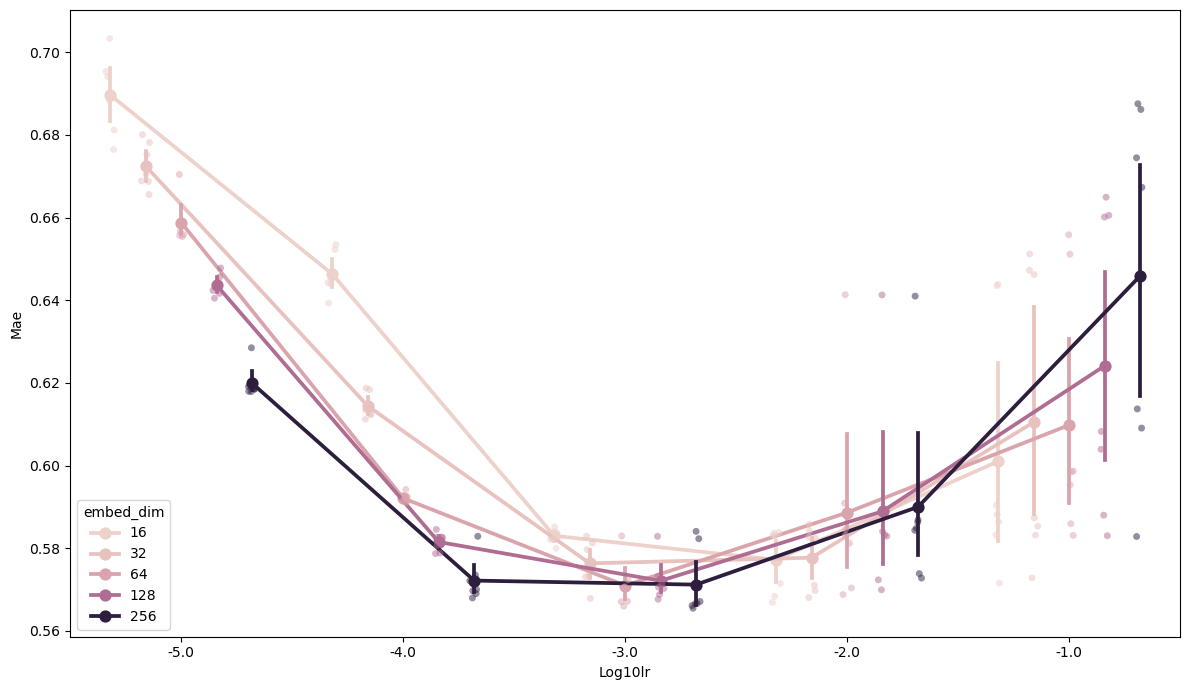

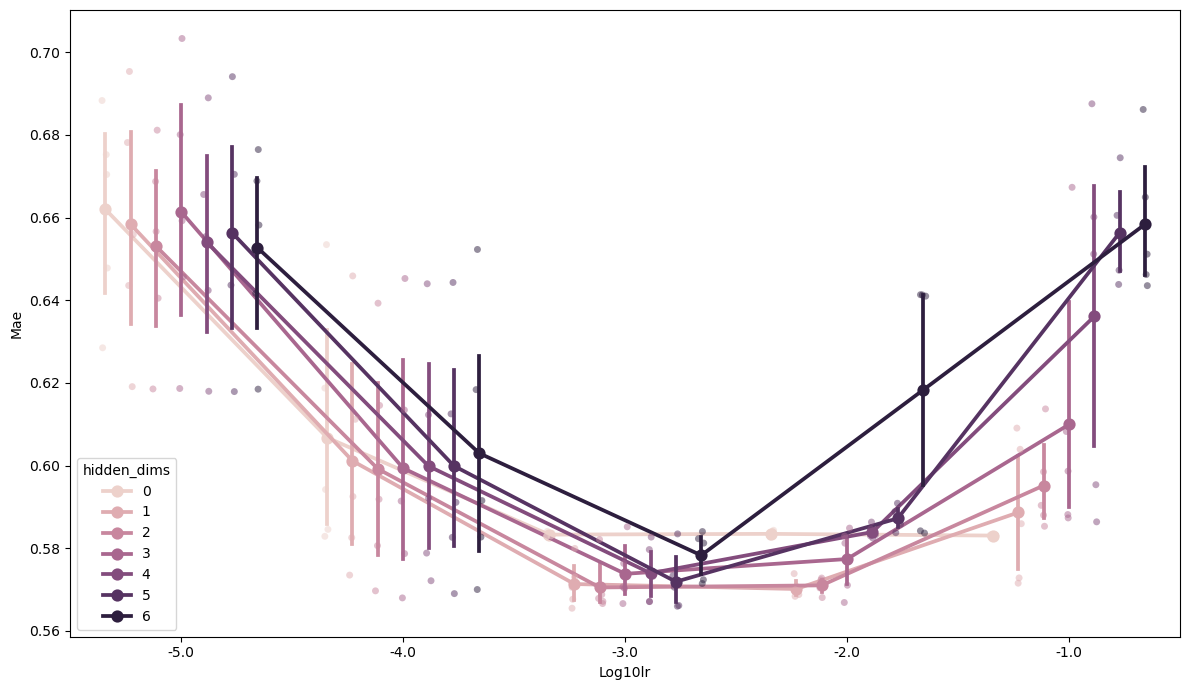

In [5]:
metric_x_point(
    df=test, 
    cols=['embed_dim', 'hidden_dims', 'log10lr'],
    metrics=['mae'],
    figsize=(12,7),
    hue=True,
    strip=True,
    dodge=True,
    sig=False
)